# Visualizing results

In [2]:
import os
import numpy as np
import pandas as pd
import plotnine as pln

In [3]:
def read_results(res_dir_path, model_name):
    res = pd.DataFrame()
    for file in os.listdir(res_dir_path):
        if file.endswith('.csv'):
            dataset = file.split('.')[0]
            df = pd.read_csv(os.path.join(res_dir_path, file), index_col=0)
            df['Dataset'] = dataset
            res = pd.concat([res, df], ignore_index=True)
    res['Model'] = model_name
    return res

# Viral x Non-viral proteins

In [4]:
prot_lengths = {}

# viral proteins
for prot in os.listdir('../data/viral/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/viral/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

# non-viral proteins
for prot in os.listdir('../data/cellular/metadata/'):
    if prot.endswith('.csv'):
        df = pd.read_csv(os.path.join('../data/cellular/metadata/', prot), index_col=0)
        prot_lengths[prot.split('.csv')[0]] = int(df['sequence'].apply(lambda x: len(x)).mean())

In [5]:
cols = ['Fold', 'R2_score_train', 'MAE_score_train', 'RMSE_score_train',
       'R2_score_test', 'MAE_score_test', 'RMSE_score_test', 'rho_score_train',
       'rho_score_test', 'dataset', 'Model', 'Source']

In [6]:
res_full = pd.DataFrame()
for source in ['viral', 'cellular']:
    for method in ['pool_split', 'site_split']:
        res_dir_path = f'../experiments/lassoCV/esm2_650m/{source}/{method}/'
        res = read_results(res_dir_path, 'esm2_base')
        res['Source'] = source
        res['Split'] = method
        
        if method == 'pool_split':
            res['Split'] = 'pooled'
        elif method == 'site_split':
            res['Split'] = 'site'
        res_full = pd.concat([res_full, res], ignore_index=True)


res_full['prot_length'] = res_full['Dataset'].map(prot_lengths)
res_full

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,num_nonzero_coefs,Dataset,Source,Split,prot_length
0,esm2_base,1,0.595066,0.465875,0.642610,0.499775,0.496724,0.678049,0.623398,0.544245,267,SARS2_PRD0038_RBD_Starr,viral,pooled,200
1,esm2_base,2,0.603862,0.452948,0.627526,0.520908,0.502435,0.700182,0.624444,0.596304,276,SARS2_PRD0038_RBD_Starr,viral,pooled,200
2,esm2_base,3,0.589508,0.472382,0.652183,0.407867,0.495722,0.709779,0.622881,0.528574,246,SARS2_PRD0038_RBD_Starr,viral,pooled,200
3,esm2_base,1,0.452034,0.520602,0.729537,0.231151,0.688557,0.925848,0.627984,0.397335,44,HIV1_HV1B9_ENV_DuenasDecamp,viral,pooled,853
4,esm2_base,2,0.503739,0.510456,0.698138,0.244454,0.645255,0.898591,0.658186,0.418242,53,HIV1_HV1B9_ENV_DuenasDecamp,viral,pooled,853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,esm2_base,2,0.437893,0.562725,0.747542,0.278494,0.677684,0.857862,0.695225,0.550731,128,AMIE_PSEAE_Whitehead,cellular,site,346
386,esm2_base,3,0.455772,0.553156,0.735721,0.216342,0.677011,0.893326,0.714539,0.466297,146,AMIE_PSEAE_Whitehead,cellular,site,346
387,esm2_base,1,0.170798,0.669587,0.909185,0.086739,0.718926,0.961240,0.464095,0.328798,102,MK01_HUMAN_Johannessen,cellular,site,360
388,esm2_base,2,0.183786,0.665675,0.904741,0.064980,0.727102,0.955276,0.484114,0.307316,111,MK01_HUMAN_Johannessen,cellular,site,360


In [7]:
cols=['rho_score_test', 'R2_score_test', 'rho_score_train', 'R2_score_train', 'prot_length']
res_full = res_full.groupby(['Dataset', 'Split', 'Source'], as_index=False)[cols].mean()
res_full 

,Dataset,Split,Source,rho_score_test,R2_score_test,rho_score_train,R2_score_train,prot_length
0,AMIE_PSEAE_Whitehead,pooled,cellular,0.740800,0.477524,0.791640,0.589139,346.0
1,AMIE_PSEAE_Whitehead,site,cellular,0.491775,0.222458,0.665746,0.398576,346.0
2,B3VI55_LIPSTSTABLE,pooled,cellular,0.698285,0.451530,0.765475,0.557978,439.0
3,B3VI55_LIPSTSTABLE,site,cellular,0.579191,0.268583,0.660729,0.394301,439.0
4,B3VI55_LIPST_Whitehead2015,pooled,cellular,0.470285,0.245162,0.557411,0.353876,439.0
...,...,...,...,...,...,...,...,...
125,TIM_THETH,site,cellular,0.395686,0.111886,0.739881,0.540923,254.0
126,TPK1_HUMAN_Roth2017,pooled,cellular,0.412649,0.153564,0.506220,0.229386,243.0
127,TPK1_HUMAN_Roth2017,site,cellular,0.327829,0.069056,0.522287,0.249500,243.0
128,TPMT_HUMAN_Fowler2018,pooled,cellular,0.597178,0.434826,0.697484,0.561339,245.0


In [8]:
res_full.groupby(['Split', 'Source'], as_index=False)[cols].mean()

,Split,Source,rho_score_test,R2_score_test,rho_score_train,R2_score_train,prot_length
0,pooled,cellular,0.681607,0.504644,0.766009,0.643058,349.416667
1,pooled,viral,0.597091,0.382401,0.665171,0.492094,590.731707
2,site,cellular,0.473575,0.182691,0.660096,0.454222,349.416667
3,site,viral,0.338327,0.119652,0.448634,0.223620,590.731707


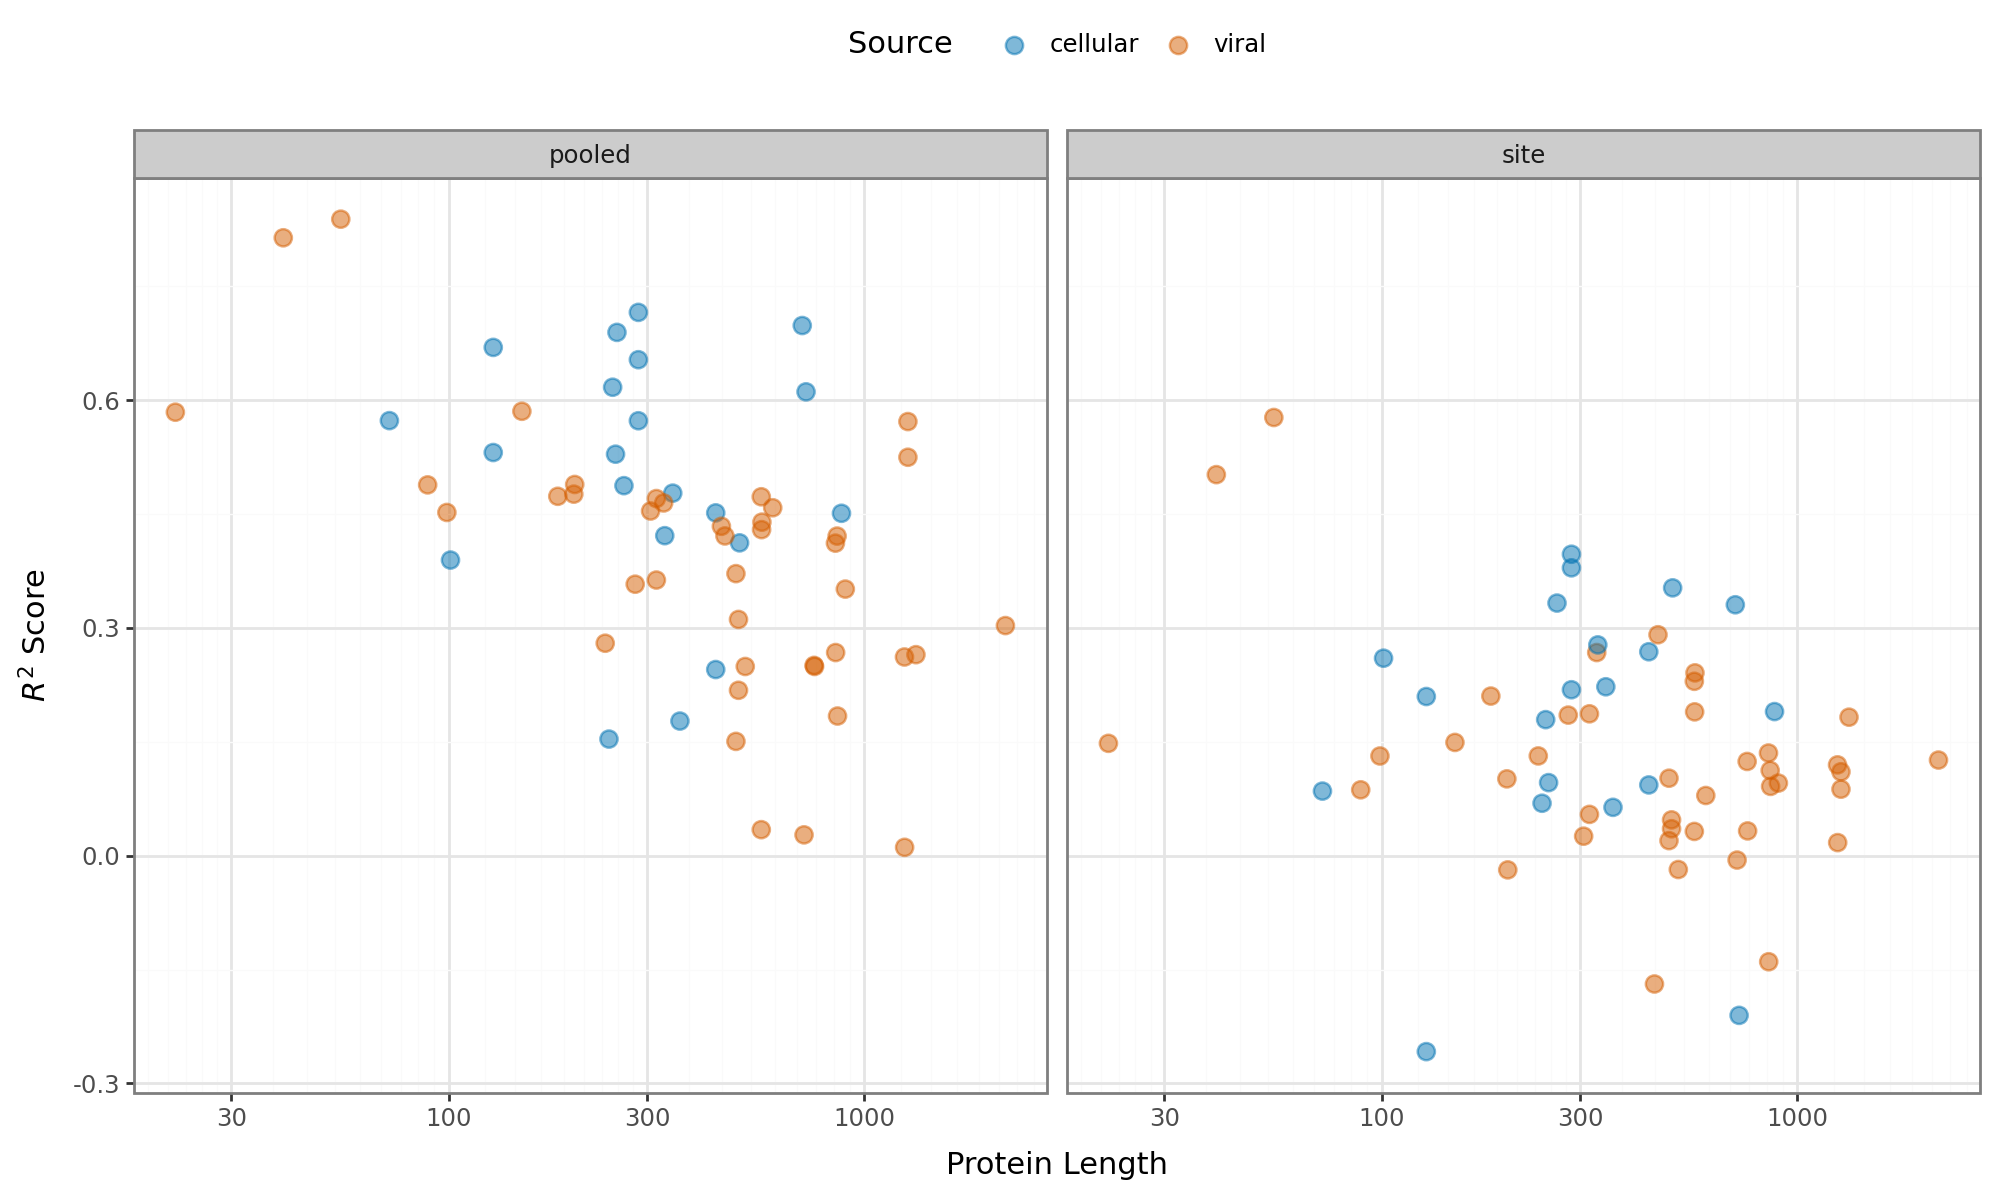

In [19]:
plot = (
    pln.ggplot(res_full, pln.aes(x='prot_length', y='R2_score_test'))
    + pln.geom_point(pln.aes(color='Source'), size=3, alpha=0.5)
    + pln.scale_color_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.facet_wrap('Split')
    + pln.scale_x_log10()
    + pln.labs(x="Protein Length", y="$R^2$ Score")
    + pln.theme_bw()
    + pln.theme(figure_size=(10, 6), legend_position='top',)
    #+ pln.ylim(-0.2, 0.8)

)
plot#.save(filename='../experiments/protein_length_vs_lassocv_r2_full.png', dpi=600)

# Fine tuned models

In [ ]:
res_full = pd.DataFrame()
for model in ['esm2_650m', 'esmc_600m', 'rsawhney_esm2_3B', 'esm2_viral_650m_MP15', 'esm2_viral_650m_MP15_partial']:
    #for source in ['viral', 'cellular']:
    for source in ['viral']:
        for method in ['pool_split', 'site_split']:
            res_dir_path = f'../experiments/lassoCV/{model}/{source}/{method}/'
            res = read_results(res_dir_path, model)
            res['Source'] = source
            res['Split'] = method
            
            res_full = pd.concat([res_full, res], ignore_index=True)

rename_map = {
    'esm2_viral_650m_MP15_partial':'esm2_viral_partial', 
    'esm2_viral_650m_MP15':'esm2_viral_full',
    'pool_split':'pooled',
    'site_split':'site',

    }

res_full.replace(rename_map, inplace=True)
res_full['prot_length'] = res_full['Dataset'].map(prot_lengths)
res_full

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,num_nonzero_coefs,Dataset,Source,Split,prot_length
0,esm2_650m,1,0.595066,0.465875,0.642610,0.499775,0.496724,0.678049,0.623398,0.544245,267,SARS2_PRD0038_RBD_Starr,viral,pooled,200
1,esm2_650m,2,0.603862,0.452948,0.627526,0.520908,0.502435,0.700182,0.624444,0.596304,276,SARS2_PRD0038_RBD_Starr,viral,pooled,200
2,esm2_650m,3,0.589508,0.472382,0.652183,0.407867,0.495722,0.709779,0.622881,0.528574,246,SARS2_PRD0038_RBD_Starr,viral,pooled,200
3,esm2_650m,1,0.452034,0.520602,0.729537,0.231151,0.688557,0.925848,0.627984,0.397335,44,HIV1_HV1B9_ENV_DuenasDecamp,viral,pooled,853
4,esm2_650m,2,0.503739,0.510456,0.698138,0.244454,0.645255,0.898591,0.658186,0.418242,53,HIV1_HV1B9_ENV_DuenasDecamp,viral,pooled,853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1225,esm2_viral_partial,2,0.347398,0.588638,0.805349,0.180584,0.655331,0.915746,0.506710,0.413510,59,SARS2_PRD0038_RBD_Starr,viral,site,200
1226,esm2_viral_partial,3,0.378709,0.601050,0.811476,0.126741,0.611219,0.812141,0.515626,0.373872,65,SARS2_PRD0038_RBD_Starr,viral,site,200
1227,esm2_viral_partial,1,0.036999,0.679493,1.019151,0.026100,0.634192,0.808336,0.299945,0.301651,12,IAV_PB2_Soh,viral,site,759
1228,esm2_viral_partial,2,0.149043,0.595464,0.833182,0.023281,0.691049,1.299657,0.447210,0.344021,84,IAV_PB2_Soh,viral,site,759


In [10]:
cols=['rho_score_test', 'R2_score_test', 'rho_score_train', 'R2_score_train']
res_full = res_full.groupby(['Dataset', 'Model', 'Split'], as_index=False)[cols].mean()
res_full 

,Dataset,Model,Split,rho_score_test,R2_score_test,rho_score_train,R2_score_train
0,BPP22_COAT_Tsuboyama,esm2_650m,pooled,0.892825,0.813831,0.949886,0.934580
1,BPP22_COAT_Tsuboyama,esm2_650m,site,0.711536,0.501893,0.902410,0.825605
2,BPP22_COAT_Tsuboyama,esm2_viral_full,pooled,0.840806,0.769198,0.946756,0.936218
3,BPP22_COAT_Tsuboyama,esm2_viral_full,site,0.423999,0.231706,0.815008,0.692935
4,BPP22_COAT_Tsuboyama,esm2_viral_partial,pooled,0.888571,0.819457,0.947676,0.932655
...,...,...,...,...,...,...,...
405,SARS2_XBB15_RBD_Taylor,esm2_viral_partial,site,0.251111,0.032039,0.480845,0.271106
406,SARS2_XBB15_RBD_Taylor,esmc_600m,pooled,0.522246,0.351564,0.586035,0.455879
407,SARS2_XBB15_RBD_Taylor,esmc_600m,site,0.186812,0.049536,0.356570,0.160648
408,SARS2_XBB15_RBD_Taylor,rsawhney_esm2_3B,pooled,0.627156,0.523283,0.706748,0.709438


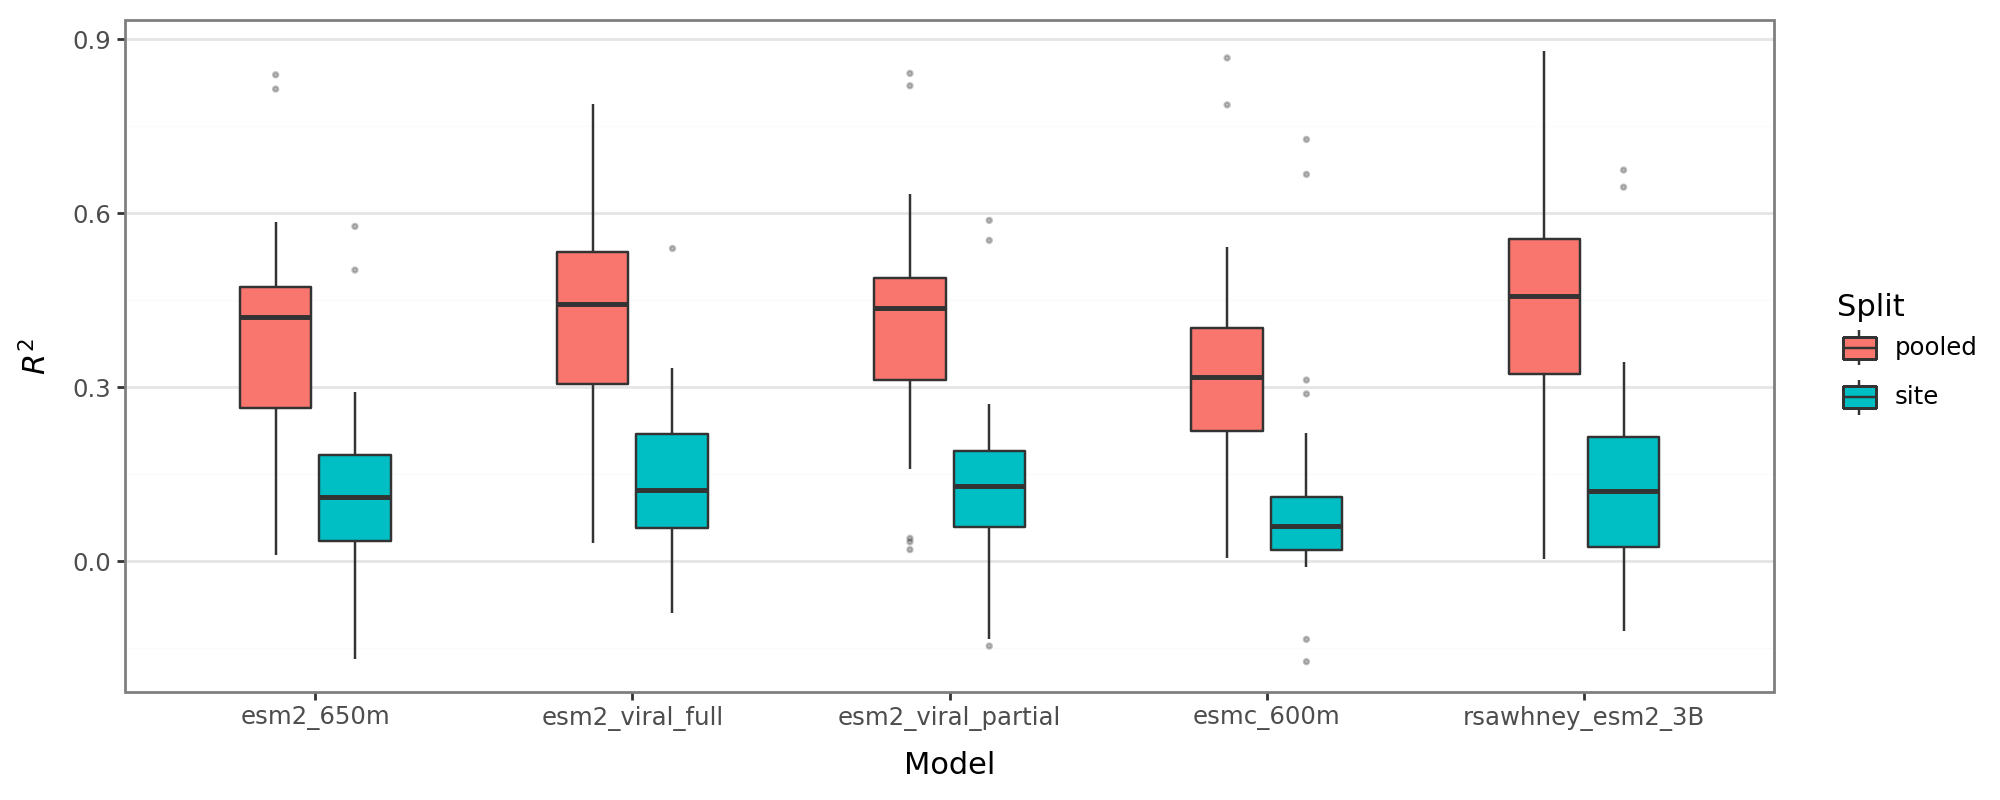

In [ ]:
plot = (
    pln.ggplot(res_full, pln.aes(x='Model', y='R2_score_test', fill='Split'))
    + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.5)
    + pln.labs(
        x='Model',
        y='$R^2$',
    )
    + pln.theme_bw()
    + pln.theme(
        figure_size=(10, 4),
        panel_grid_major_x=pln.element_blank(),
    )
)

plot

# Lasso results all models

In [1]:
import pandas as pd
import plotnine as pln

In [9]:
res = pd.read_csv('../experiments_v01/lassoCV/results_4models_3folds_v_nv_SS_P.csv', index_col=0)
res['Model'] = pd.Categorical(res['Model'], categories=['esmc_600m', 'esm2_650m', 'esm2_viral_650m', 'rsawhney_esm2_3B'], ordered=True)
res['Source'] = res['Source'].replace('nonviral', 'cellular')
res

,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,num_zero_coefs,Dataset,Dataset_Size,Prot_Length,Model,Source,Split
0,1,0.293028,0.636302,0.863418,-0.076546,0.661374,0.916954,0.414383,0.146640,40,SARS2_PRD0038_RBD_Starr,3998,200,esm2_650m,viral,site
1,2,0.185222,0.674901,0.914246,0.168593,0.656686,0.863289,0.337174,0.302062,15,SARS2_PRD0038_RBD_Starr,3998,200,esm2_650m,viral,site
2,3,0.156070,0.684361,0.914523,0.109362,0.700166,0.959868,0.297714,0.352247,17,SARS2_PRD0038_RBD_Starr,3998,200,esm2_650m,viral,site
3,1,0.270192,0.705873,0.858758,0.247014,0.694528,0.847557,0.564320,0.532887,66,IAV_H3_HA_Lee,10754,566,esm2_650m,viral,site
4,2,0.219202,0.729762,0.883830,0.172357,0.744978,0.906407,0.509140,0.459610,25,IAV_H3_HA_Lee,10754,566,esm2_650m,viral,site
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1771,2,0.697654,0.432616,0.552728,0.524055,0.529136,0.675303,0.814520,0.711667,611,PTEN_HUMAN_Fowler2018,4229,403,rsawhney_esm2_3B,cellular,pooled
1772,3,0.691392,0.427804,0.550186,0.553494,0.540224,0.692383,0.815477,0.727172,607,PTEN_HUMAN_Fowler2018,4229,403,rsawhney_esm2_3B,cellular,pooled
1773,1,0.790112,0.344433,0.459803,0.496030,0.523168,0.699376,0.835496,0.670760,283,RL401_YEAST_Fraser2016,1324,128,rsawhney_esm2_3B,cellular,pooled
1774,2,0.717256,0.395203,0.526315,0.614182,0.476788,0.643454,0.799535,0.741660,221,RL401_YEAST_Fraser2016,1324,128,rsawhney_esm2_3B,cellular,pooled


In [11]:
#ols = pd.read_csv('../experiments_v01/lassoCV/results_OLS_3folds_v_nv_Pooled.csv', index_col=0)
avg = pd.read_csv('../experiments/AVG/results_AVG_3folds_all.csv', index_col=0)
avg

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,Dataset,Source,Split
0,AVG,1,0.530925,0.511884,0.683361,0.424830,0.567484,0.765066,0.734405,0.669716,SARS2_PLPRO_abundance_Wu,viral,pooled
1,AVG,2,0.521827,0.515027,0.691632,0.461210,0.551556,0.732446,0.731561,0.683581,SARS2_PLPRO_abundance_Wu,viral,pooled
2,AVG,3,0.527835,0.510688,0.683042,0.433635,0.573968,0.768914,0.733999,0.671194,SARS2_PLPRO_abundance_Wu,viral,pooled
0,AVG,1,0.632854,0.422123,0.603981,0.673508,0.412015,0.578420,0.761273,0.792606,LAMBDA_HCP_Tsuboyama,viral,pooled
1,AVG,2,0.625207,0.427129,0.611822,0.692847,0.410369,0.553779,0.770798,0.752323,LAMBDA_HCP_Tsuboyama,viral,pooled
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,AVG,2,0.000000,0.812128,0.994095,-0.048830,0.766907,1.028071,NaN,NaN,RASH_HUMAN_Kuriyan,cellular,site
2,AVG,3,0.000000,0.774200,0.987168,-0.017285,0.852537,1.049883,NaN,NaN,RASH_HUMAN_Kuriyan,cellular,site
0,AVG,1,0.000000,0.820263,1.008093,-0.002555,0.806109,0.967561,NaN,NaN,AMIE_PSEAE_Whitehead,cellular,site
1,AVG,2,0.000000,0.814106,0.997071,-0.003854,0.846865,1.011889,NaN,NaN,AMIE_PSEAE_Whitehead,cellular,site


In [12]:
cols = avg.columns
res = res[cols].copy()

In [13]:
full_res = pd.concat([res, avg])
#full_res = full_res.query('Split == "pooled"')
full_res

,Model,Fold,R2_score_train,MAE_score_train,RMSE_score_train,R2_score_test,MAE_score_test,RMSE_score_test,rho_score_train,rho_score_test,Dataset,Source,Split
0,esm2_650m,1,0.293028,0.636302,0.863418,-0.076546,0.661374,0.916954,0.414383,0.146640,SARS2_PRD0038_RBD_Starr,viral,site
1,esm2_650m,2,0.185222,0.674901,0.914246,0.168593,0.656686,0.863289,0.337174,0.302062,SARS2_PRD0038_RBD_Starr,viral,site
2,esm2_650m,3,0.156070,0.684361,0.914523,0.109362,0.700166,0.959868,0.297714,0.352247,SARS2_PRD0038_RBD_Starr,viral,site
3,esm2_650m,1,0.270192,0.705873,0.858758,0.247014,0.694528,0.847557,0.564320,0.532887,IAV_H3_HA_Lee,viral,site
4,esm2_650m,2,0.219202,0.729762,0.883830,0.172357,0.744978,0.906407,0.509140,0.459610,IAV_H3_HA_Lee,viral,site
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,AVG,2,0.000000,0.812128,0.994095,-0.048830,0.766907,1.028071,NaN,NaN,RASH_HUMAN_Kuriyan,cellular,site
2,AVG,3,0.000000,0.774200,0.987168,-0.017285,0.852537,1.049883,NaN,NaN,RASH_HUMAN_Kuriyan,cellular,site
0,AVG,1,0.000000,0.820263,1.008093,-0.002555,0.806109,0.967561,NaN,NaN,AMIE_PSEAE_Whitehead,cellular,site
1,AVG,2,0.000000,0.814106,0.997071,-0.003854,0.846865,1.011889,NaN,NaN,AMIE_PSEAE_Whitehead,cellular,site


In [14]:
full_res['Model'] = pd.Categorical(full_res['Model'], ordered=True, categories=['AVG', 'esm2_viral_650m', 'rsawhney_esm2_3B', 'esm2_650m', 'esmc_600m', 
       ])

In [16]:
df_mean = full_res.groupby(['Source', 'Split', 'Model', 'Dataset', ], as_index=False)['R2_score_test'].mean()
df_mean 

/tmp/ipykernel_2410336/619895380.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,Source,Split,Model,Dataset,R2_score_test
0,cellular,pooled,AVG,AMIE_PSEAE_Whitehead,0.405258
1,cellular,pooled,AVG,B3VI55_LIPSTSTABLE,0.254094
2,cellular,pooled,AVG,B3VI55_LIPST_Whitehead2015,0.162333
3,cellular,pooled,AVG,BG_STRSQ_hmmerbit,0.102000
4,cellular,pooled,AVG,BLAT_ECOLX_Ostermeier2014,0.455095
...,...,...,...,...,...
1475,viral,site,esmc_600m,TPK1_HUMAN_Roth2017,NaN
1476,viral,site,esmc_600m,TPMT_HUMAN_Fowler2018,NaN
1477,viral,site,esmc_600m,UBC9_HUMAN_Roth2017,NaN
1478,viral,site,esmc_600m,UBE4B_MOUSE_Klevit2013_singles,NaN


/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 740 rows containing non-finite values.


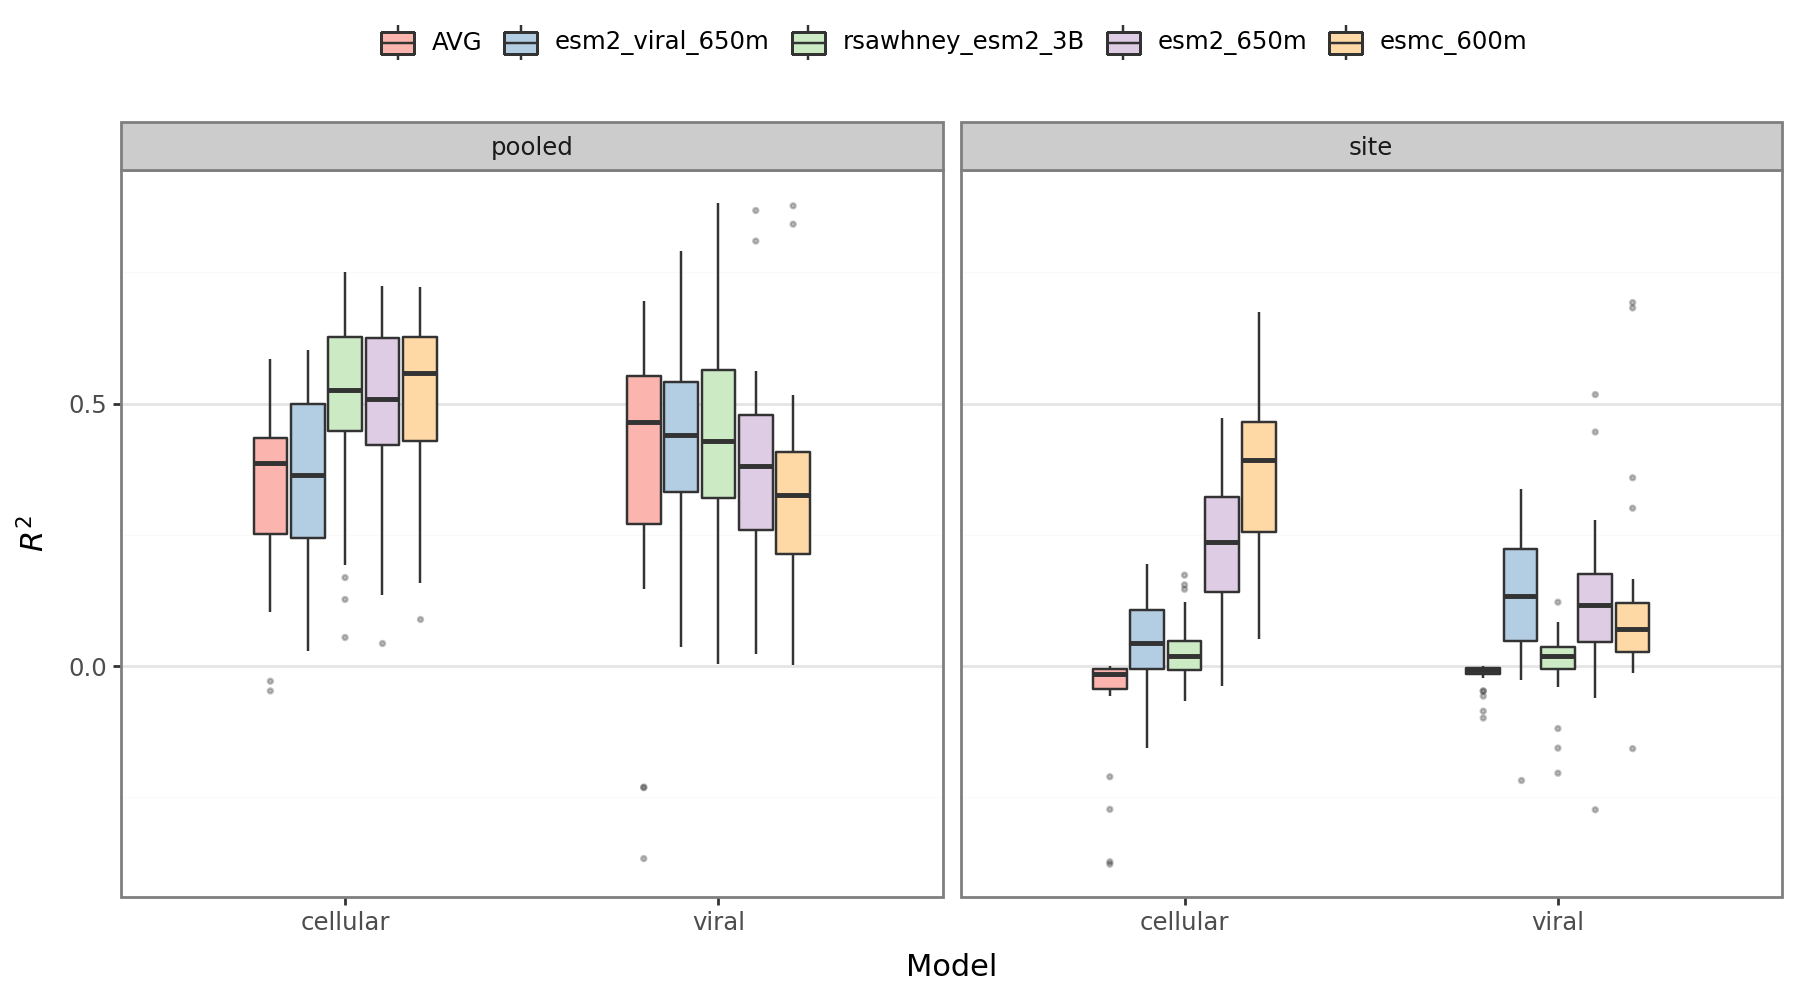

In [55]:
plot = (
    pln.ggplot(df_mean , pln.aes(x='Source', y='R2_score_test', fill='Model'))
    + pln.geom_boxplot(outlier_size=0.5, outlier_alpha=0.3, width=0.5)
    #+ pln.scale_color_manual(values={"viral": "#D55E00", "nonviral": "#0072B2"})
    + pln.scale_fill_brewer(palette='Pastel1', type='qual')
    + pln.labs(
        x='Model',
        y='$R^2$',
    )
    + pln.theme_bw()
    + pln.facet_grid('~ Split')
    + pln.theme(
        figure_size=(9, 5),
        panel_grid_major_x=pln.element_blank(),
        legend_position='top',
        legend_title=pln.element_blank()
    )
)

plot#.save(filename='../experiments/lassoCV_x_AVG_all.png', dpi=600)